<a href="https://colab.research.google.com/github/Knchna/Credit_Default_Preprocessing/blob/Kanchana/Credit_Default_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clone the Git

In [11]:
# Clone the GitHub repository into the Google Colab environment

!git clone https://github.com/Knchna/Credit_Default_Preprocessing.git

fatal: destination path 'Credit_Default_Preprocessing' already exists and is not an empty directory.


# Libraries

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# Read the Data

In [13]:
# filepath to the .excel file
# Load the dataset from the cloned GitHub repository

filepath = '/content/Credit_Default_Preprocessing/default of credit card clients.xls'
df_credit = pd.read_excel(filepath, header=1)
df_credit.head(20)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


## Correlation

In [14]:
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

target_col = 'default payment next month'

In [15]:
# Finding Pearson's correlation coefficient to measure linear relationship b/w continuous numerical columns

# Matrix 1: to find any mutli-collinearity b/w the 14 numerical features
corr_mat_num = df_credit[num_cols].corr()
corr_mat_num

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
LIMIT_BAL,1.000000,0.144713,0.285430,0.278314,0.283236,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595
AGE,0.144713,1.000000,0.056239,0.054283,0.053710,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478
BILL_AMT1,0.285430,0.056239,1.000000,0.951484,0.892279,0.860272,0.829779,0.802650,0.140277,0.099355,0.156887,0.158303,0.167026,0.179341
BILL_AMT2,0.278314,0.054283,0.951484,1.000000,0.928326,0.892482,0.859778,0.831594,0.280365,0.100851,0.150718,0.147398,0.157957,0.174256
BILL_AMT3,0.283236,0.053710,0.892279,0.928326,1.000000,0.923969,0.883910,0.853320,0.244335,0.316936,0.130011,0.143405,0.179712,0.182326
BILL_AMT4,0.293988,0.051353,0.860272,0.892482,0.923969,1.000000,0.940134,0.900941,0.233012,0.207564,0.300023,0.130191,0.160433,0.177637
BILL_AMT5,0.295562,0.049345,0.829779,0.859778,0.883910,0.940134,1.000000,0.946197,0.217031,0.181246,0.252305,0.293118,0.141574,0.164184
BILL_AMT6,0.290389,0.047613,0.802650,0.831594,0.853320,0.900941,0.946197,1.000000,0.199965,0.172663,0.233770,0.250237,0.307729,0.115494
PAY_AMT1,0.195236,0.026147,0.140277,0.280365,0.244335,0.233012,0.217031,0.199965,1.000000,0.285576,0.252191,0.199558,0.148459,0.185735
PAY_AMT2,0.178408,0.021785,0.099355,0.100851,0.316936,0.207564,0.181246,0.172663,0.285576,1.000000,0.244770,0.180107,0.180908,0.157634


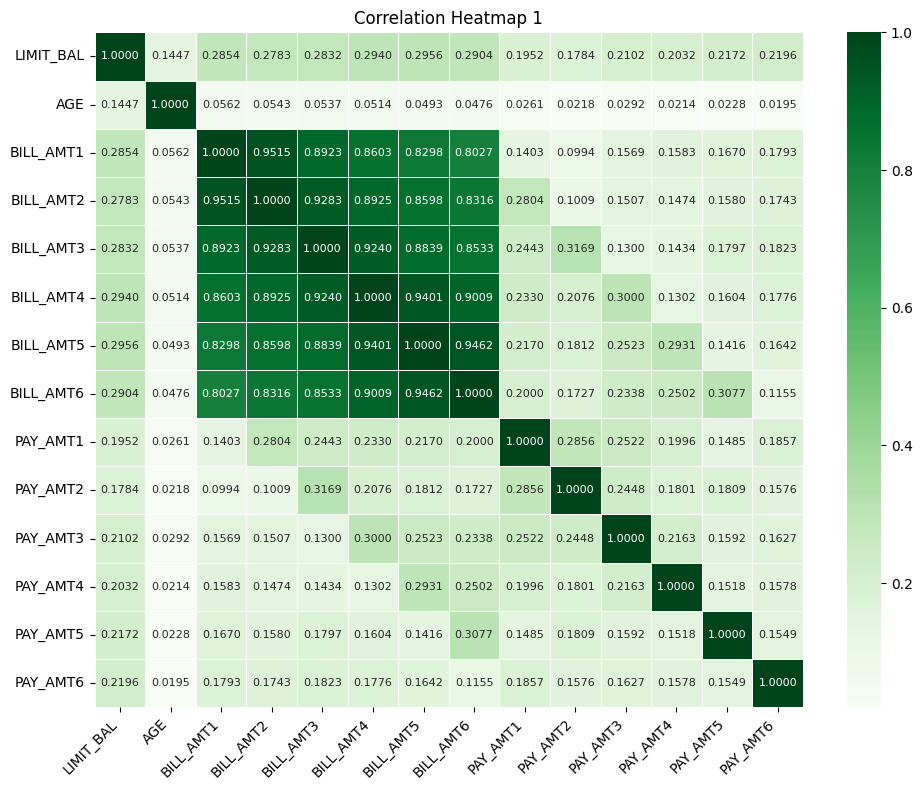

In [16]:
# Correlation Heatmap 1: of only numerical feature cols

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_mat_num,
    annot=True,
    fmt=".4f",
    cmap="Greens",
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title('Correlation Heatmap 1')

plt.tight_layout()
plt.show()

In [17]:
# Inference:
    # The BILL_AMT variables exhibit high positive correlations, especially b/w adjacent months.
    # This is because they represent the same customer's financial behaviour across 6 consecutive months.
    # Correlation decreases as the time gap between months increases, reflecting changes in spending over time.
    # Since these features capture historical information rather than duplicate measurements, they were retained despite multicollinearity

In [18]:
# Matrix 2: to check collinearity b/w the 14 numerical features and target feature
corr_mat_target = df_credit[num_cols + ['default payment next month']].corr()
corr_mat_target['default payment next month']

,default payment next month
LIMIT_BAL,-0.153520
AGE,0.013890
BILL_AMT1,-0.019644
BILL_AMT2,-0.014193
BILL_AMT3,-0.014076
BILL_AMT4,-0.010156
BILL_AMT5,-0.006760
BILL_AMT6,-0.005372
PAY_AMT1,-0.072929
PAY_AMT2,-0.058579


In [19]:
# Inference:
  # Correlation analysis showed that most continuous numerical features have weak linear relationships with the target variable.
  # Note: In target col -> higher value = 1 (default), lower value = 0 (no default)

  # LIMIT_BAL exhibited the strongest linear relationship (r = -0.154),
      # -ve indicates that customers with higher credit limits tend to have a lower probability of default (i.e., target col val is 0)

  # The PAY_AMT variables also showed weak negative correlations,
      # suggesting that larger repayment amounts are associated with a reduced likelihood of default

  # The BILL_AMT variables and AGE show negligible linear correlations with target.


# Since Pearson correlation captures only linear associations, these results will be complemented with Mutual Information analysis,
    # to identify features that may have more relevant non-linear relationships with the target.

## Mutual Information

In [20]:
# defining target col y
y = df_credit[target_col]

# defining feature cols as X
X = df_credit.drop(columns = target_col)

# using classif MI, as the target col is binary and several features are continuous numerical
# discrete features can be identified by parameter 'discrete = ',
    # but it requires either a Boolean mask OR list/array of those column indices

# creating Boolean mask, this creates an Boolean array of columns in X, indicating presence/absence of cat_cols in it using True/False
discrete_mask = X.columns.isin(cat_cols)
discrete_mask


array([False, False,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False])

In [21]:
# Mutual Information Classifier - to detect non-linear relationships b/w features and target
mi = mutual_info_classif(X, y, discrete_features = discrete_mask, random_state = 42)
mi

array([0.00519971, 0.01638017, 0.00079304, 0.00307847, 0.00061015,
       0.0003498 , 0.07605263, 0.04905609, 0.0372781 , 0.0328878 ,
       0.0305436 , 0.02642224, 0.01227792, 0.00587979, 0.00718942,
       0.003323  , 0.00760984, 0.00483543, 0.02359127, 0.01345467,
       0.01706371, 0.01441829, 0.01695853, 0.01195396])

In [22]:
# Converting mi array to Series with index as the column names of X
mi_scores = pd.Series(mi, index = X.columns, name = "Mutual Information")
mi_scores = mi_scores.sort_values(ascending = False)
mi_scores

,Mutual Information
PAY_0,0.076053
PAY_2,0.049056
PAY_3,0.037278
PAY_4,0.032888
PAY_5,0.030544
PAY_6,0.026422
PAY_AMT1,0.023591
PAY_AMT3,0.017064
PAY_AMT5,0.016959
LIMIT_BAL,0.016380


In [23]:
# Inference:
  # The repayment status variables (PAY_0–PAY_6) exhibited the highest predictive feature importance
  # demographic variables - AGE, EDUCATION, SEX and MARRIAGE showed relatively low mutual information

# However, these features were retained because:
    # they represent meaningful customer characteristics
    # did not show any multicollinearity
    # they may contribute to the target through interactions with other variables
    # Dropping 2 cols out of 23 doesn't help much to increase dimensionality or reduce computational load

# If absolutely required, cols SEX and MARRIAGE can be dropped as they show almost 0 MI.